# Pairs Plots

Two variables have one joint distribution, so `.plot()` just draws it. Three or more have
no single "the plot" -- there are three pairs among three variables, six among four -- so
`.plot()` draws a **matrix** of panels instead:

- **down the diagonal**, each variable on its own;
- **below the diagonal**, each pair together;
- **above the diagonal**, each joint panel's colorbar, named for the pair it explains.

Panel *(i, j)* and panel *(j, i)* would show the same relationship with the axes swapped,
so only the lower triangle is filled and the upper one carries the colorbars.

The same matrix is drawn two ways, and this notebook covers both: from **simulated data**
(`RVResults`, estimated from the draws) and from a **distribution** (exact, computed from
its pdf or pmf). They share their layout deliberately, so a simulation can be read side by
side with the distribution it came from.

In [1]:
from symbulate import *

# Simulated pairs plots

Every panel shows exactly what that data would show on its own, estimated from the
draws: a histogram or an impulse plot down the diagonal, a 2-D histogram or a tile
plot below it.

## Three continuous variables

Simulate a trivariate normal whose first two variables are strongly related and whose third
is nearly independent of them. Each diagonal panel is a **density** curve; each panel below
it is a **2-D histogram**, with color for how much of the data landed in each bin.

Currently Showing: Pairs Plot (Default)
Alternative Plots: Path Plot (type = "path")


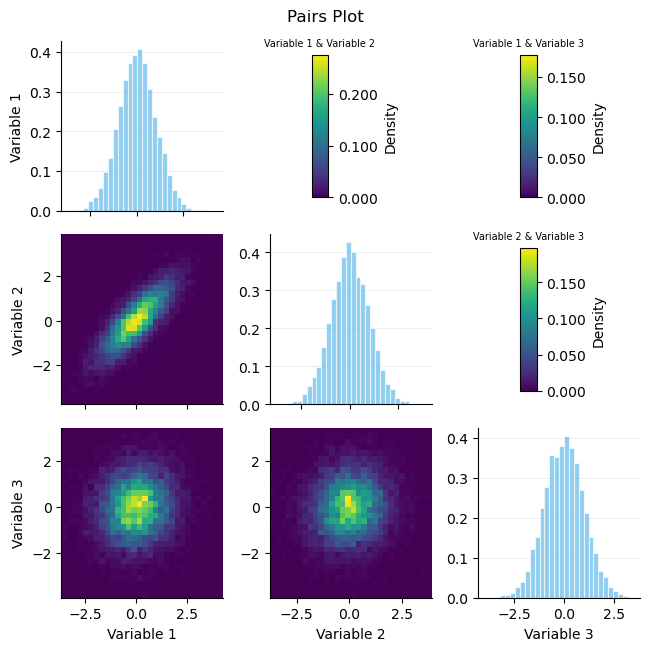

In [2]:
X = RV(MultivariateNormal(mean=[0, 0, 0],
                          cov=[[1.0, 0.8, 0.1],
                               [0.8, 1.0, 0.1],
                               [0.1, 0.1, 1.0]]))
sim = X.sim(10000)
sim.plot()

The `Variable 1`-`Variable 2` panel is a tight diagonal ridge (correlation 0.8) while the two panels
involving `Variable 3` are round blobs (correlation 0.1) -- which is the relationship the matrix
exists to make visible at a glance.

Compare it with the exact distribution, drawn the same way:

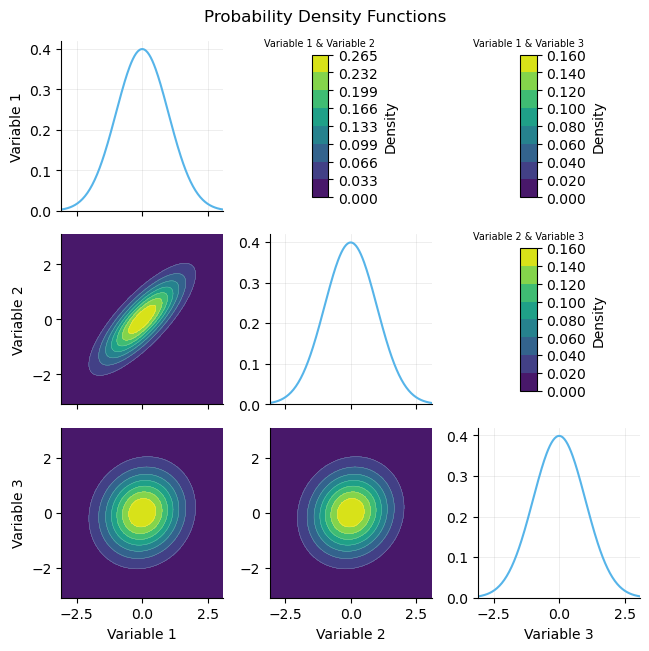

In [3]:
MultivariateNormal(mean=[0, 0, 0],
                   cov=[[1.0, 0.8, 0.1],
                        [0.8, 1.0, 0.1],
                        [0.1, 0.1, 1.0]]).plot()

## Discrete variables

When a variable takes only a handful of values, a density curve would smear a probability
mass function into a smooth curve it isn't -- so the diagonal switches to an **impulse**
plot, and the joint panels become **tile** plots, one cell per combination.

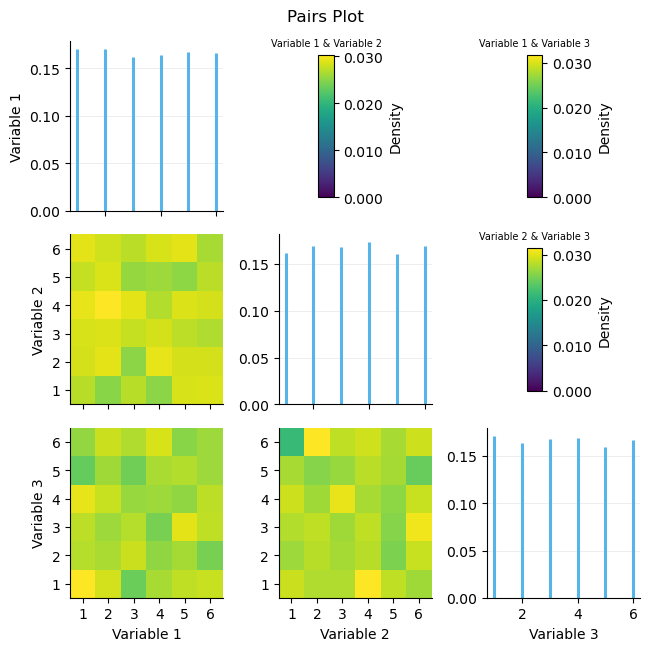

In [4]:
rolls = RV(BoxModel([1, 2, 3, 4, 5, 6], size=3))
rolls.sim(10000).plot()

Three independent dice, so every cell holds about the same share of the data and no panel
shows any structure -- exactly what independence should look like here.

## A mix of discrete and continuous

Each panel is chosen from the pair it shows, so a mixed pair gets a tile plot with the
continuous axis binned. Here a die roll decides which of three normal distributions a
measurement comes from.

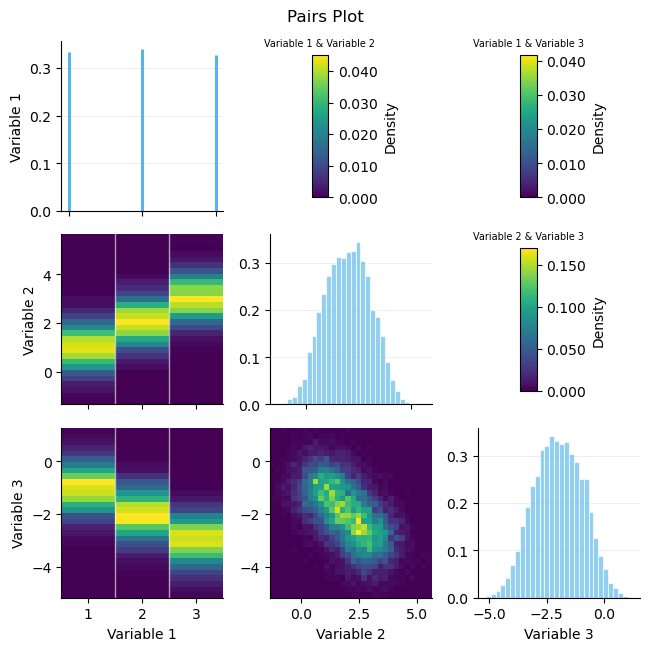

In [5]:
# A group label (1, 2 or 3), and two measurements whose centers depend on it.
def draw_one():
    group = BoxModel([1, 2, 3]).draw()
    return (group,
            Normal(mean=group, sd=0.7).draw(),
            Normal(mean=-group, sd=0.7).draw())

grouped = RV(ProbabilitySpace(draw_one))
grouped.sim(10000).plot()

The `Variable 1`-`Variable 2` panel shows the measurement shifting up as the group label rises, and the
`Variable 1`-`Variable 3` panel shows it shifting down -- read off the discrete axis one column of cells at
a time.

## Choosing which variables to show

A matrix grows quickly: six variables would need 21 panels. Index the random variable to pick the ones worth looking at, numbered from 0 --
`Y[[0, 2, 4]]` is the 1st, 3rd and 5th.

The old plot — one connected line per realization against its index — is still
available as `type="path"`.

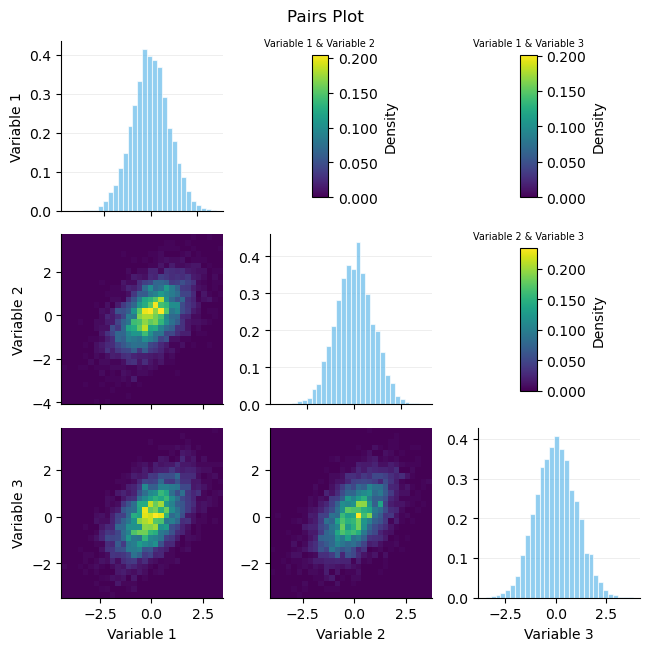

In [6]:
Y = RV(MultivariateNormal(mean=[0] * 5, cov=[[1.0 if i == j else 0.5 for j in range(5)]
                                             for i in range(5)]))
five = Y.sim(5000)
Y[[0, 2, 4]].sim(5000).plot()  # just the 1st, 3rd and 5th

## Notes on a simulated matrix

- Every panel in a column covers the same variable with the same number of bins, so the
  columns can be compared directly. Pass `bins=` to change that number for the whole matrix.
- The matrix fills the figure, so it cannot share one with another plot -- a second `.plot()`
  in the same cell raises an error rather than drawing on top of a panel.
- Panels show densities by default; `normalize=False` switches the whole matrix to raw
  counts.

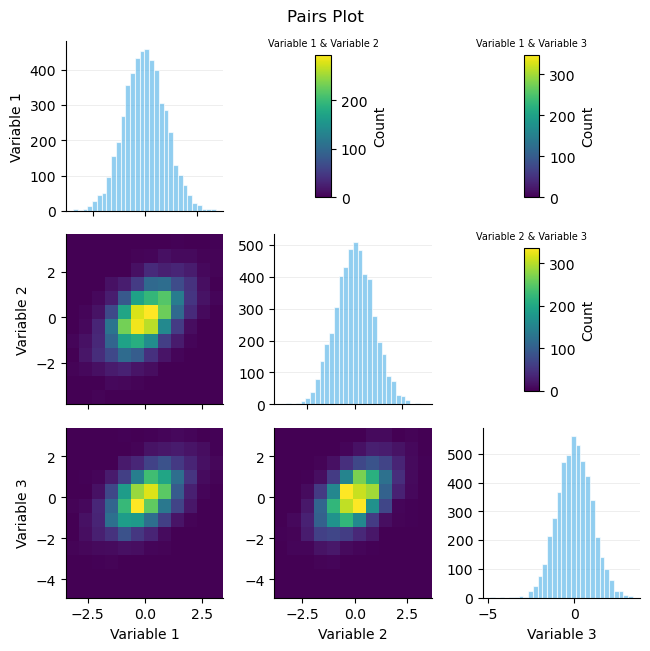

In [7]:
Y[[0, 1, 2]].sim(5000).plot(bins=12, normalize=False)

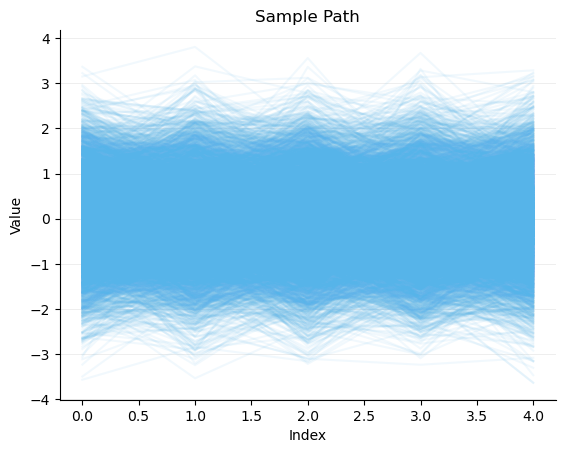

In [8]:
# type = "path" creates previous default sample path plot
five.plot(type="path")

# Theoretical pairs plots

A `MultivariateDistribution` draws the same matrix from its *exact* distribution -- every
panel is computed, not estimated, so no simulation is involved and no sample size is
needed. The title says which kind of function is being shown: **Probability Density
Functions** for a continuous family, **Probability Mass Functions** for a discrete one.

## Continuous: probability density functions

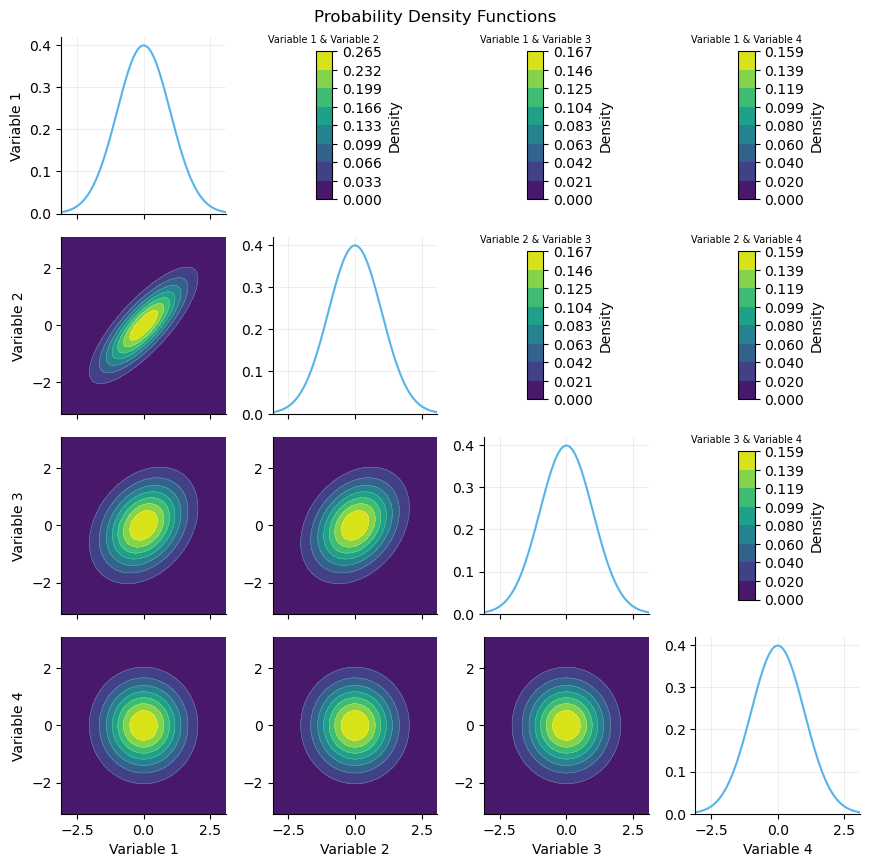

In [9]:
MultivariateNormal(mean=[0, 0, 0, 0],
                   cov=[[1.0, 0.8, 0.3, 0.0],
                        [0.8, 1.0, 0.3, 0.0],
                        [0.3, 0.3, 1.0, 0.0],
                        [0.0, 0.0, 0.0, 1.0]]).plot()

Each panel is a smooth density surface, and the last variable's panels are round blobs
because it is uncorrelated with the rest.

## Discrete: probability mass functions

A discrete family has probabilities at the values it can actually take, so its panels are
grids of cells rather than smooth surfaces, and each colorbar reads **Probability**.

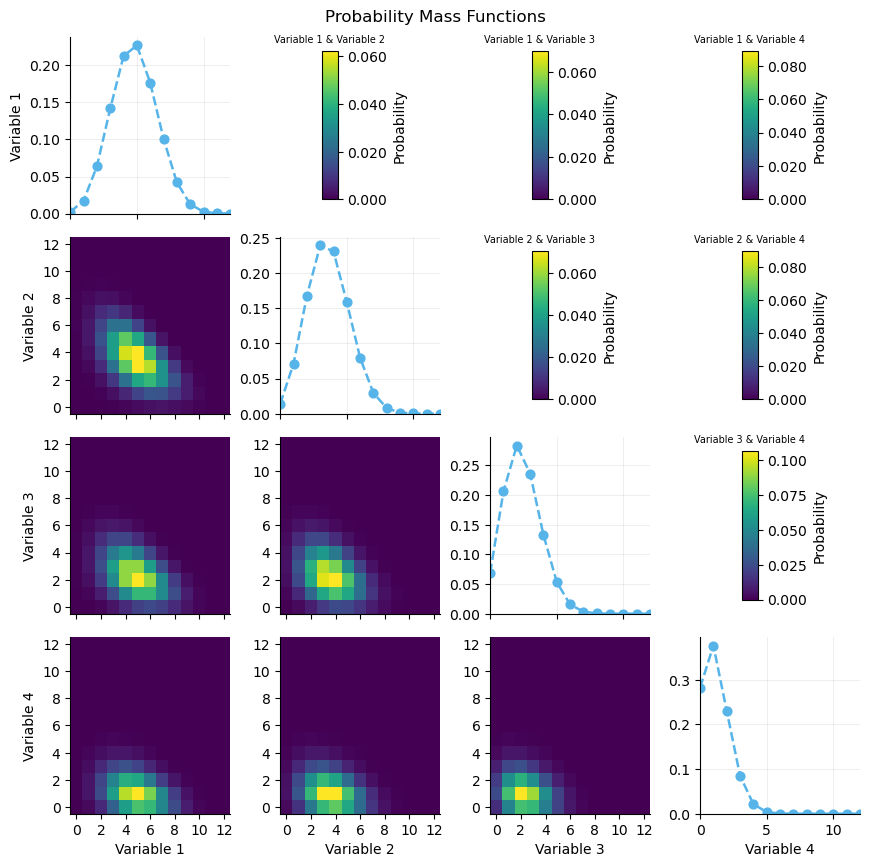

In [10]:
Multinomial(n=12, p=[0.4, 0.3, 0.2, 0.1]).plot()

The dark anti-diagonal band in each joint panel is the constraint at work: the counts have
to add to `n = 12`, so a large count for one category forces the others down.

That constraint also decides how many variables there are to plot. A `Multinomial` with
three categories has only **two** that vary freely -- the third is whatever is left over --
so it has a single joint distribution and draws one plot rather than a matrix:

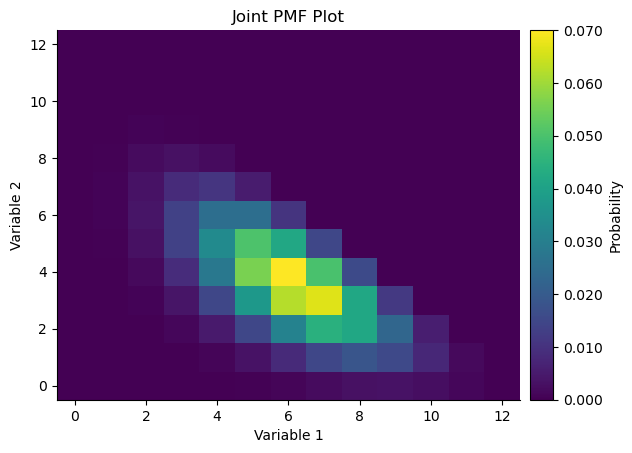

In [11]:
Multinomial(n=12, p=[0.5, 0.3, 0.2]).plot()

A distribution chooses its variables with `variables=`, taking any two or more of
them, numbered from 0 — so `variables=[0, 2, 4]` draws the 1st, 3rd and 5th. (For
simulated results there is no such argument: index the random variable before
simulating, `X[[0, 2, 4]].sim(n)`, which is the same idea one step earlier.)

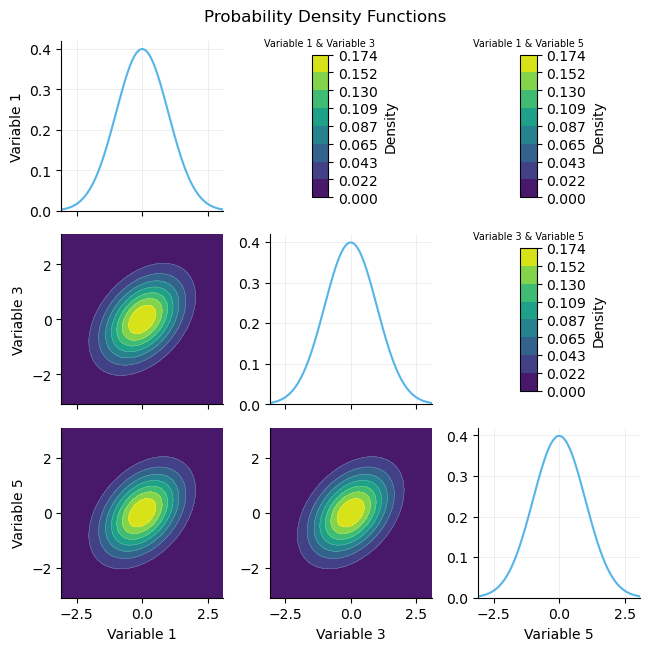

In [12]:
big = MultivariateNormal(mean=[0] * 5,
                         cov=[[1.0 if i == j else 0.4 for j in range(5)]
                              for i in range(5)])
big.plot(variables=[0, 2, 4])  # the 1st, 3rd and 5th of five variables